In [1]:
!pip install prophet

  Using cached prophet-1.3.0-py3-none-win_amd64.whl.metadata (3.6 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached prophet-1.3.0-py3-none-win_amd64.whl (12.1 MB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 5.0 MB/s  0:00:00
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)
Using cached stanio-0.5.1-py3-none-any.whl (8.1 kB)

   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   

In [3]:
import os
import sys

# Change the notebook's active working directory to the project root
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

# Ensure the root path is also in sys.path
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())


In [4]:
import pandas as pd

import matplotlib.pyplot as plt

from prophet import Prophet

from src.database.connection import DatabaseConnection

In [5]:
conn = DatabaseConnection.connect()

In [6]:
## load daily sales data from database
query = """
SELECT
    date,
    SUM(sales) AS sales


FROM sales_enriched

GROUP BY date

ORDER BY date
"""

In [7]:
daily_sales = pd.read_sql(query, conn)

C:\Users\Dell\AppData\Local\Temp\ipykernel_23996\2181589959.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  daily_sales = pd.read_sql(query, conn)


In [8]:
daily_sales

,date,sales
0,2011-01-29,32631.0
1,2011-01-30,31749.0
2,2011-01-31,23783.0
3,2011-02-01,25412.0
4,2011-02-02,19146.0
...,...,...
1908,2016-04-20,35343.0
1909,2016-04-21,35033.0
1910,2016-04-22,40517.0
1911,2016-04-23,48962.0


In [11]:
## since prophet expects ds and y columns

daily_sales = daily_sales.rename(
    columns={
        'date': 'ds',
        'sales': 'y'
    }
)

daily_sales['ds'] = pd.to_datetime(
    daily_sales['ds']
)


In [12]:
daily_sales.head()

,ds,y
0,2011-01-29,32631.0
1,2011-01-30,31749.0
2,2011-01-31,23783.0
3,2011-02-01,25412.0
4,2011-02-02,19146.0


In [ ]:
## lets train the model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

In [15]:
model.fit(daily_sales)

15:17:05 - cmdstanpy - INFO - Chain [1] start processing
15:17:05 - cmdstanpy - INFO - Chain [1] done processing


In [16]:
## forecast

future = model.make_future_dataframe(
    periods = 365
)

forecast = model.predict(future)

In [17]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2011-01-29,23412.578537,25910.216093,35117.885970,23412.578537,23412.578537,6976.764832,6976.764832,6976.764832,7223.402014,7223.402014,7223.402014,-246.637182,-246.637182,-246.637182,0.0,0.0,0.0,30389.343369
1,2011-01-30,23426.957945,25776.847393,34523.224054,23426.957945,23426.957945,6635.915351,6635.915351,6635.915351,6797.164150,6797.164150,6797.164150,-161.248799,-161.248799,-161.248799,0.0,0.0,0.0,30062.873296
2,2011-01-31,23441.337353,17714.507594,26389.992659,23441.337353,23441.337353,-1538.862007,-1538.862007,-1538.862007,-1464.982908,-1464.982908,-1464.982908,-73.879099,-73.879099,-73.879099,0.0,0.0,0.0,21902.475346
3,2011-02-01,23455.716761,15048.408641,24204.595883,23455.716761,23455.716761,-3943.043929,-3943.043929,-3943.043929,-3958.588262,-3958.588262,-3958.588262,15.544333,15.544333,15.544333,0.0,0.0,0.0,19512.672831
4,2011-02-02,23470.096169,15035.890335,23619.266239,23470.096169,23470.096169,-4219.770984,-4219.770984,-4219.770984,-4326.719952,-4326.719952,-4326.719952,106.948968,106.948968,106.948968,0.0,0.0,0.0,19250.325185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2273,2017-04-20,46074.553994,37230.254656,46349.973371,44701.993687,47459.287541,-4452.639906,-4452.639906,-4452.639906,-4141.014792,-4141.014792,-4141.014792,-311.625115,-311.625115,-311.625115,0.0,0.0,0.0,41621.914087
2274,2017-04-21,46087.040557,40763.939393,50344.685445,44707.425830,47475.572059,-505.886897,-505.886897,-505.886897,-129.260250,-129.260250,-129.260250,-376.626647,-376.626647,-376.626647,0.0,0.0,0.0,45581.153660
2275,2017-04-22,46099.527120,48076.015871,57641.674143,44712.857974,47488.326960,6783.810302,6783.810302,6783.810302,7223.402014,7223.402014,7223.402014,-439.591712,-439.591712,-439.591712,0.0,0.0,0.0,52883.337422
2276,2017-04-23,46112.013683,47633.670714,56739.991660,44718.290118,47503.962802,6296.783964,6296.783964,6296.783964,6797.164150,6797.164150,6797.164150,-500.380186,-500.380186,-500.380186,0.0,0.0,0.0,52408.797646


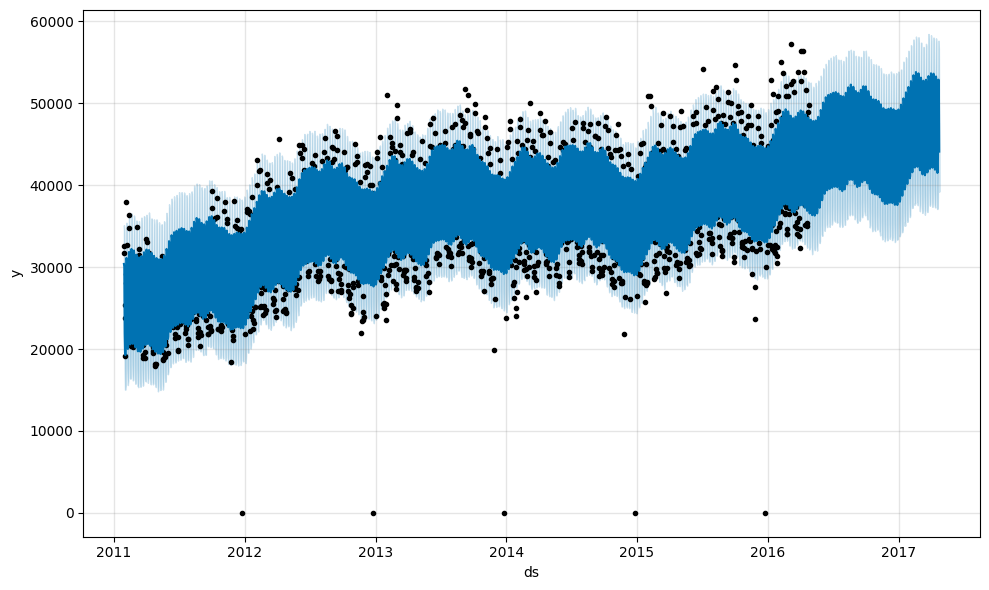

In [18]:
## forecast plot

fig = model.plot(forecast)

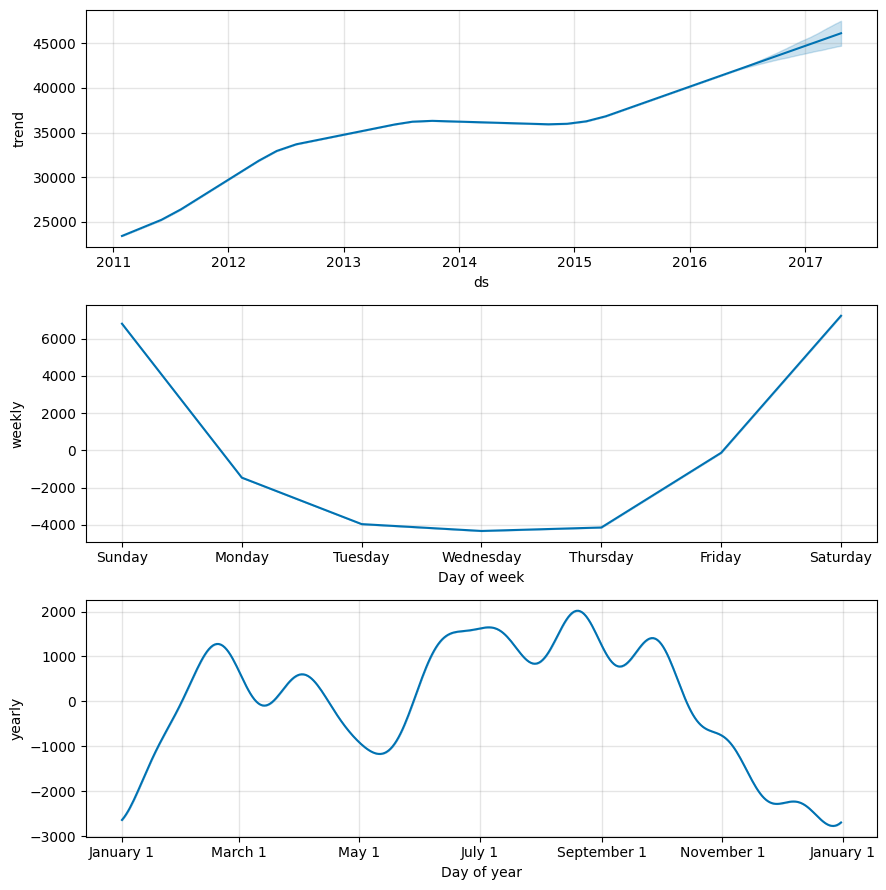

In [19]:
## components plot
fig = model.plot_components(forecast)

### Cross Validation

In [21]:
from prophet.diagnostics import cross_validation

In [22]:
df_cv = cross_validation(
    model,
    initial = '730 days',
    period = '180 days',
    horizon = '365 days'
)

  0%|          | 0/5 [00:00<?, ?it/s]

15:21:51 - cmdstanpy - INFO - Chain [1] start processing
15:21:51 - cmdstanpy - INFO - Chain [1] done processing
15:21:52 - cmdstanpy - INFO - Chain [1] start processing
15:21:52 - cmdstanpy - INFO - Chain [1] done processing
15:21:52 - cmdstanpy - INFO - Chain [1] start processing
15:21:52 - cmdstanpy - INFO - Chain [1] done processing
15:21:53 - cmdstanpy - INFO - Chain [1] start processing
15:21:53 - cmdstanpy - INFO - Chain [1] done processing
15:21:53 - cmdstanpy - INFO - Chain [1] start processing
15:21:53 - cmdstanpy - INFO - Chain [1] done processing


In [25]:
from prophet.diagnostics import performance_metrics

metrics = performance_metrics(df_cv)

In [26]:
metrics.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,37 days,1.184885e+07,3442.215674,2747.199824,0.079275,0.065407,0.078409,0.791209
1,38 days,1.166847e+07,3415.914264,2711.156592,0.078380,0.063285,0.077514,0.792308
2,39 days,1.167146e+07,3416.351955,2712.472780,0.078401,0.063246,0.077588,0.794505
3,40 days,1.163422e+07,3410.897752,2712.543183,0.078307,0.063744,0.077508,0.800000
4,41 days,1.163542e+07,3411.073595,2715.540405,0.078227,0.063246,0.077432,0.802198


In [27]:
## average metrics

metrics.mean(numeric_only=True)

mse         1.978039e+07
rmse        4.382268e+03
mae         3.323019e+03
mape        5.253729e+00
mdape       7.486964e-02
smape       9.357781e-02
coverage    7.029627e-01
dtype: float64

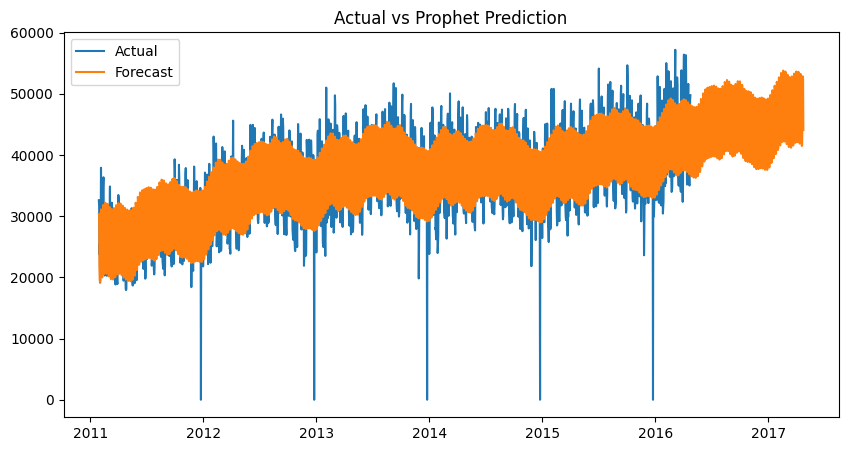

In [29]:
## visualize forecast accuracy
plt.figure(figsize=(10,5))

plt.plot(
    daily_sales["ds"],
    daily_sales["y"],
    label="Actual"
)

plt.plot(
    forecast["ds"],
    forecast["yhat"],
    label="Forecast"
)

plt.legend()

plt.title("Actual vs Prophet Prediction")

plt.show()